In [ ]:
import pandas as pd
df = pd.read_csv('/content/cleaned_data.csv')
df.head()

,Timestamp,sex,age,ofteneatbug,ofteneatnoodle,commentwithbug,allergic,noodletype,buyingfactor,productform,...,purchaseplace_ร้านขายอุปกรณ์กีฬา/ฟิตเนส,purchaseplace_ร้านค้าออนไลน์(Shopee/Lazada/TikTok),purchaseplace_ร้านสะดวกซื้อทั่วไป,purchaseplace_ร้านอาหารเพื่อสุขภาพโดยเฉพาะ,health_and_efficiency,environment_and_ethics,Innovation,risk,comfort,price_sen
0,1/7/2026 1:26:27,0,0,0,0,0,1,0,0,0,...,0,1,1,0,1,3,5,2,1,1
1,1/7/2026 7:02:54,0,0,0,1,0,1,1,0,1,...,0,1,0,0,3,0,5,3,2,1
2,1/7/2026 8:19:57,0,0,0,1,1,1,1,0,1,...,0,1,1,0,5,0,1,3,2,3
3,1/7/2026 8:41:09,0,0,0,2,0,1,0,0,2,...,0,1,1,0,3,0,5,2,1,1
4,1/7/2026 8:44:46,0,0,1,2,1,1,1,0,0,...,1,1,1,1,5,0,0,4,2,0


In [ ]:
features = [
    'health_and_efficiency',
    'environment_and_ethics',
    'Innovation',
    'risk',
    'comfort',
    'price_sen'
]

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df[features]
X_scaled = StandardScaler().fit_transform(X)


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

K = range(1, 11)   # ทดลอง 1–10 clusters

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


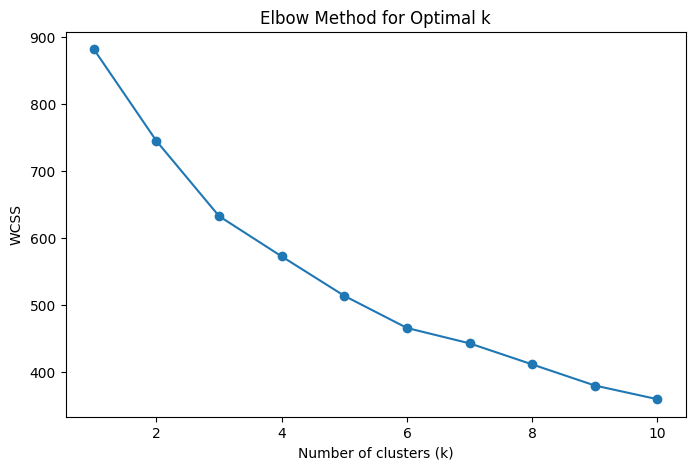

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(K, wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()


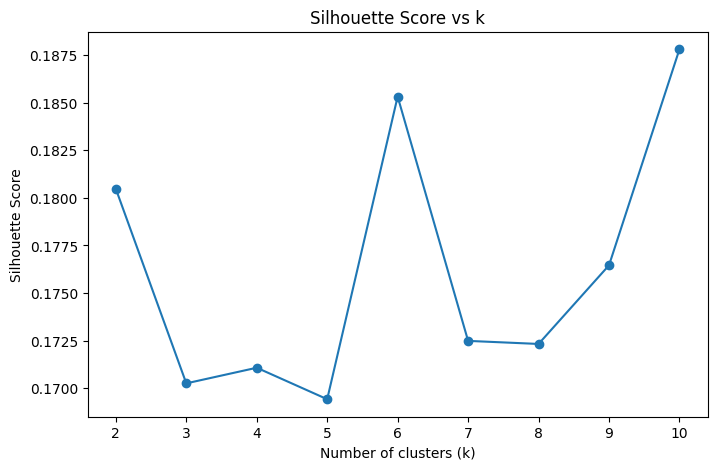

In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8,5))
plt.plot(range(2,11), sil_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs k')
plt.show()


In [ ]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)


In [ ]:
df.groupby('cluster_kmeans')[
    ['health_and_efficiency','environment_and_ethics','Innovation',
     'risk','comfort','price_sen','age','sex']
].mean()


,health_and_efficiency,environment_and_ethics,Innovation,risk,comfort,price_sen,age,sex
cluster_kmeans,,,,,,,,
0,3.727273,1.136364,3.136364,3.954545,0.681818,3.272727,0.227273,0.363636
1,3.343750,0.437500,4.312500,1.781250,1.906250,0.875000,0.500000,0.437500
2,4.600000,0.800000,4.120000,2.080000,0.280000,1.400000,0.600000,0.360000
3,1.684211,3.578947,3.000000,1.947368,1.105263,1.789474,0.052632,0.526316
4,3.033333,0.200000,1.200000,3.133333,1.166667,0.900000,0.166667,0.400000
5,3.368421,0.105263,1.947368,1.684211,1.473684,3.000000,0.526316,0.631579


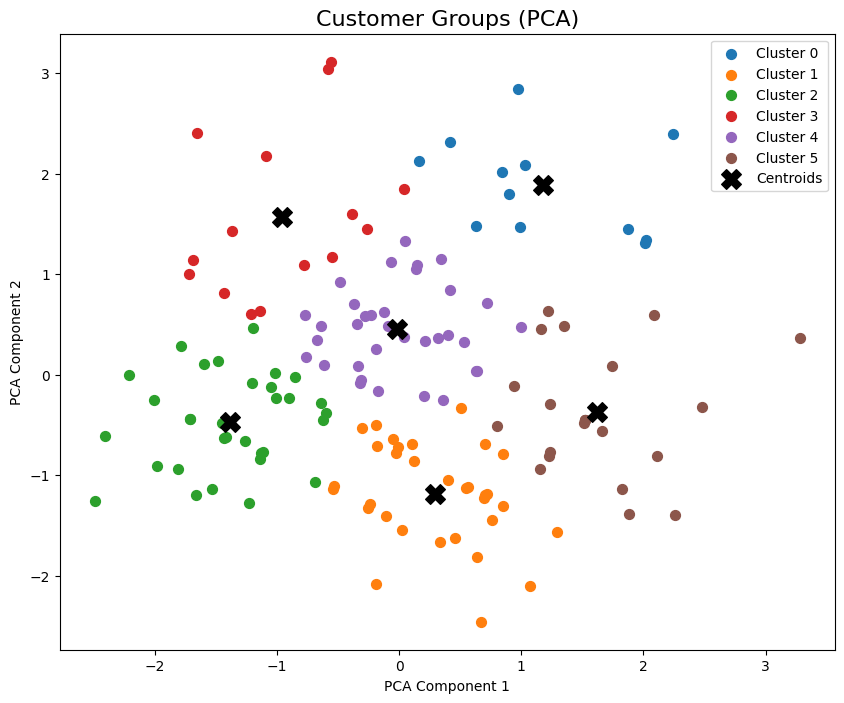

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca)
centroids = kmeans.cluster_centers_

plt.figure(figsize=(10, 8))

for i in range(6):
    plt.scatter(
        X_pca[labels == i, 0],
        X_pca[labels == i, 1],
        s=50,
        label=f'Cluster {i}'
    )

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title('Customer Groups (PCA)', fontsize=16)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()


In [ ]:
df

,Timestamp,sex,age,ofteneatbug,ofteneatnoodle,commentwithbug,allergic,noodletype,buyingfactor,productform,...,purchaseplace_ร้านค้าออนไลน์(Shopee/Lazada/TikTok),purchaseplace_ร้านสะดวกซื้อทั่วไป,purchaseplace_ร้านอาหารเพื่อสุขภาพโดยเฉพาะ,health_and_efficiency,environment_and_ethics,Innovation,risk,comfort,price_sen,cluster_kmeans
0,1/7/2026 1:26:27,0,0,0,0,0,1,0,0,0,...,1,1,0,1,3,5,2,1,1,3
1,1/7/2026 7:02:54,0,0,0,1,0,1,1,0,1,...,1,0,0,3,0,5,3,2,1,1
2,1/7/2026 8:19:57,0,0,0,1,1,1,1,0,1,...,1,1,0,5,0,1,3,2,3,5
3,1/7/2026 8:41:09,0,0,0,2,0,1,0,0,2,...,1,1,0,3,0,5,2,1,1,1
4,1/7/2026 8:44:46,0,0,1,2,1,1,1,0,0,...,1,1,1,5,0,0,4,2,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,1/8/2026 18:35:26,0,0,0,1,0,1,1,0,2,...,1,0,0,1,3,3,3,2,3,3
143,1/8/2026 22:57:22,0,0,0,0,0,0,2,4,2,...,0,1,1,5,0,3,5,0,3,0
144,1/9/2026 8:37:56,0,0,0,1,3,0,1,0,1,...,1,1,0,1,0,5,3,2,1,1
145,1/9/2026 11:30:10,1,1,1,2,0,1,1,0,0,...,1,0,0,3,0,1,3,2,3,5


In [ ]:
rawdata = pd.read_csv('/content/data.csv')

In [ ]:
cols_to_merge = [
    'Timestamp',
    'health_and_efficiency',
    'environment_and_ethics',
    'Innovation',
    'risk',
    'comfort',
    'price_sen',
    'cluster_kmeans'
]

df_feat_selected = df[cols_to_merge]
df_feat_selected

,Timestamp,health_and_efficiency,environment_and_ethics,Innovation,risk,comfort,price_sen,cluster_kmeans
0,2026-01-07 01:26:27,1,3,5,2,1,1,3
1,2026-01-07 07:02:54,3,0,5,3,2,1,1
2,2026-01-07 08:19:57,5,0,1,3,2,3,5
3,2026-01-07 08:41:09,3,0,5,2,1,1,1
4,2026-01-07 08:44:46,5,0,0,4,2,0,4
...,...,...,...,...,...,...,...,...
142,2026-01-08 18:35:26,1,3,3,3,2,3,3
143,2026-01-08 22:57:22,5,0,3,5,0,3,0
144,2026-01-09 08:37:56,1,0,5,3,2,1,1
145,2026-01-09 11:30:10,3,0,1,3,2,3,5


In [ ]:
import pandas as pd

# Ensure 'Timestamp' columns are in datetime format for both dataframes
rawdata['Timestamp'] = pd.to_datetime(rawdata['Timestamp'])
df_feat_selected['Timestamp'] = pd.to_datetime(df_feat_selected['Timestamp'])

# Merge rawdata (left) with df_feat_selected (right) on the 'Timestamp' column.
# A left merge keeps all rows from rawdata and adds matching columns from df_feat_selected.
merged_rawdata_with_features = pd.merge(rawdata, df_feat_selected, on='Timestamp', how='left')

# Display the first few rows of the new merged DataFrame
display(merged_rawdata_with_features.head())

/tmp/ipython-input-3506058059.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_feat_selected['Timestamp'] = pd.to_datetime(df_feat_selected['Timestamp'])


,Timestamp,เพศ,ช่วงอายุ,ไลฟ์สไตล์ปัจจุบันของคุณ (เลือกได้มากกว่า 1 ข้อ),"คุณเคยรับประทานเมนูที่ทำจาก ""แมลง"" หรือไม่?","ปกติคุณรับประทานเมนูประเภท ""เส้น"" บ่อยแค่ไหน?","เมื่อพูดถึง ""เส้นก๋วยเตี๋ยวหรือเส้นบะหมี่ที่มีส่วนผสมจากผงจิ้งหรีด"" คุณรู้สึกอย่างไร?","คุณมีอาการแพ้ ""อาหารทะเล"" (กุ้ง, กั้ง, ปู) หรือ ""ไรฝุ่น"" \nหรือไม่ ?","ถ้าผลิตภัณฑ์นี้ออกมาเป็นรูปแบบ ""เส้นที่มีส่วนผสมของผงจิ้งหรีด"" เพื่อให้ตอบโจทย์ความสะดวกและโปรตีนสูง คุณอยากให้เส้นนี้เป็นประเภทใดมากที่สุด ?","หากเส้นนี้มีคุณสมบัติดังนี้ ข้อใดมีผลให้คุณ ""อยากซื้อ"" มากที่สุด?",...,คุณคาดหวังจะซื้อผลิตภัณฑ์นี้ได้จากที่ไหน? (เลือกได้มากกว่า1ข้อ),หากราคาผลิตภัณฑ์นี้สูงกว่าผลิตภัณฑ์เส้นปกติทั่วไป 20-30% เพื่อแลกกับคุณค่าทางโภชนาการและสารอาหารที่สูงขึ้น คุณยอมรับได้หรือไม่?,ถ้าคุณมีโอกาสแนะนำ คุณอยากบอกอะไรเพื่อให้ทำผลิตภัณฑ์นี้ออกมาได้ถูกใจคุณมากที่สุด?,health_and_efficiency,environment_and_ethics,Innovation,risk,comfort,price_sen,cluster_kmeans
0,2026-01-07 01:26:27,ชาย,18-24,"ผู้ที่ชอบทดลองอาหารใหม่ ๆ / นวัตกรรมอาหาร, ผู้...",เคย (ทานเป็นตัวๆ),1-2 ครั้งต่อสัปดาห์,น่าสนใจ แต่ขอดูข้อมูล/รีวิวก่อน,ไม่มีอาการแพ้,เส้นราเมน / บะหมี่ญี่ปุ่น,โปรตีนสูงกว่าเส้นปกติ 3 เท่า,...,"ร้านสะดวกซื้อทั่วไป, ร้านค้าออนไลน์ (Shopee/La...",ยอมรับได้ หากรสชาติอร่อยจริง,NaN,1,3,5,2,1,1,3
1,2026-01-07 07:02:54,ชาย,18-24,ผู้ที่ต้องการความสะดวกและรวดเร็วในการเตรียมอาห...,เคย (ทานเป็นตัวๆ),ทุกวัน / เกือบทุกวัน,น่าสนใจ แต่ขอดูข้อมูล/รีวิวก่อน,ไม่มีอาการแพ้,"เส้นก๋วยเตี๋ยวแบบไทย (เช่น เส้นเล็ก, เส้นหมี่)",โปรตีนสูงกว่าเส้นปกติ 3 เท่า,...,ร้านค้าออนไลน์ (Shopee/Lazada/TikTok),ยอมรับได้ หากรสชาติอร่อยจริง,NaN,3,0,5,3,2,1,1
2,2026-01-07 08:19:57,ชาย,18-24,นักกีฬา / คนที่ออกกำลังกายสร้างกล้ามเนื้อ,เคย (ทานเป็นตัวๆ),ทุกวัน / เกือบทุกวัน,รู้สึกไม่ค่อยดี / ไม่กล้าลอง,ไม่มีอาการแพ้,"เส้นก๋วยเตี๋ยวแบบไทย (เช่น เส้นเล็ก, เส้นหมี่)",โปรตีนสูงกว่าเส้นปกติ 3 เท่า,...,"ร้านสะดวกซื้อทั่วไป, ร้านค้าออนไลน์ (Shopee/La...",ยอมรับได้ หากรสชาติอร่อยจริง,NaN,5,0,1,3,2,3,5
3,2026-01-07 08:41:09,ชาย,18-24,ผู้ที่ต้องการความสะดวกและรวดเร็วในการเตรียมอาห...,เคย (ทานเป็นตัวๆ),3-4 ครั้งต่อสัปดาห์,น่าสนใจ แต่ขอดูข้อมูล/รีวิวก่อน,ไม่มีอาการแพ้,เส้นราเมน / บะหมี่ญี่ปุ่น,โปรตีนสูงกว่าเส้นปกติ 3 เท่า,...,"ร้านสะดวกซื้อทั่วไป, ร้านค้าออนไลน์ (Shopee/La...",ยอมรับได้ หากรสชาติอร่อยจริง,NaN,3,0,5,2,1,1,1
4,2026-01-07 08:44:46,ชาย,18-24,นักกีฬา / คนที่ออกกำลังกายสร้างกล้ามเนื้อ,ไม่เคยเลย,3-4 ครั้งต่อสัปดาห์,รู้สึกไม่ค่อยดี / ไม่กล้าลอง,ไม่มีอาการแพ้,"เส้นก๋วยเตี๋ยวแบบไทย (เช่น เส้นเล็ก, เส้นหมี่)",โปรตีนสูงกว่าเส้นปกติ 3 เท่า,...,"ร้านสะดวกซื้อทั่วไป, ร้านค้าออนไลน์ (Shopee/La...",ยอมรับได้แน่นอน,NaN,5,0,0,4,2,0,4


In [ ]:
merged_rawdata_with_features.to_csv('merged_data.csv', index=False)